Recommends books that are popular among all users, regardless of who the current user is.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
books = pd.read_csv("../data/books_clean.csv")
ratings = pd.read_csv("../data/explicit_ratings.csv")

In [3]:
print("Books:", books.shape)
print("Ratings:", ratings.shape)

books.head()

Books: (271360, 8)
Ratings: (383842, 3)


,ISBN,Book_Title,Book_Author,Year_Of_Publication,Publisher,Image_URL_S,Image_URL_M,Image_URL_L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002.0,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001.0,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991.0,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999.0,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999.0,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [4]:
rating_count = (
    ratings
    .groupby("ISBN")
    .agg(num_ratings=("Book_Rating", "count"))
    .reset_index()
)

rating_count.head()

,ISBN,num_ratings
0,0000913154,1
1,0001046438,1
2,000104687X,1
3,0001047213,1
4,0001047973,2


In [ ]:
# Calculate average rating for each book
rating_mean = (
    ratings
    .groupby("ISBN")
    .agg(avg_rating=("Book_Rating", "mean"))
    .reset_index()
)

rating_mean.head()

,ISBN,avg_rating
0,0000913154,8.0
1,0001046438,9.0
2,000104687X,6.0
3,0001047213,9.0
4,0001047973,9.0


In [ ]:
# merge count and avg rating into a single dataframe
popularity_df = rating_count.merge(
    rating_mean,
    on="ISBN"
)

popularity_df.head()

,ISBN,num_ratings,avg_rating
0,0000913154,1,8.0
1,0001046438,1,9.0
2,000104687X,1,6.0
3,0001047213,1,9.0
4,0001047973,2,9.0


In [7]:
# merge book information

popularity_df = popularity_df.merge(
    books,
    on="ISBN"
)

popularity_df.head()

,ISBN,num_ratings,avg_rating,Book_Title,Book_Author,Year_Of_Publication,Publisher,Image_URL_S,Image_URL_M,Image_URL_L
0,0000913154,1,8.0,The Way Things Work: An Illustrated Encycloped...,C. van Amerongen (translator),1967.0,Simon &amp; Schuster,http://images.amazon.com/images/P/0000913154.0...,http://images.amazon.com/images/P/0000913154.0...,http://images.amazon.com/images/P/0000913154.0...
1,0001046438,1,9.0,Liar,Stephen Fry,1996.0,Harpercollins Uk,http://images.amazon.com/images/P/0001046438.0...,http://images.amazon.com/images/P/0001046438.0...,http://images.amazon.com/images/P/0001046438.0...
2,000104687X,1,6.0,"T.S. Eliot Reading \The Wasteland\"" and Other ...",T.S. Eliot,1993.0,HarperCollins Publishers,http://images.amazon.com/images/P/000104687X.0...,http://images.amazon.com/images/P/000104687X.0...,http://images.amazon.com/images/P/000104687X.0...
3,0001047213,1,9.0,The Fighting Man,Gerald Seymour,1993.0,HarperCollins Publishers,http://images.amazon.com/images/P/0001047213.0...,http://images.amazon.com/images/P/0001047213.0...,http://images.amazon.com/images/P/0001047213.0...
4,0001047973,2,9.0,Brave New World,Aldous Huxley,1999.0,Trafalgar Square Publishing,http://images.amazon.com/images/P/0001047973.0...,http://images.amazon.com/images/P/0001047973.0...,http://images.amazon.com/images/P/0001047973.0...


In [ ]:
# filter books with at least 50 ratings as min threshold for popularity
popular_books = popularity_df[
    popularity_df["num_ratings"] >= 50
]

In [9]:
# sort

popular_books = popular_books.sort_values(
    by="avg_rating",
    ascending=False
)

popular_books.head(20)

,ISBN,num_ratings,avg_rating,Book_Title,Book_Author,Year_Of_Publication,Publisher,Image_URL_S,Image_URL_M,Image_URL_L
24538,0345339738,77,9.402597,"The Return of the King (The Lord of the Rings,...",J.R.R. TOLKIEN,1986.0,Del Rey,http://images.amazon.com/images/P/0345339738.0...,http://images.amazon.com/images/P/0345339738.0...,http://images.amazon.com/images/P/0345339738.0...
46135,0439139597,137,9.262774,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,2000.0,Scholastic,http://images.amazon.com/images/P/0439139597.0...,http://images.amazon.com/images/P/0439139597.0...,http://images.amazon.com/images/P/0439139597.0...
46428,043936213X,53,9.207547,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,2001.0,Scholastic,http://images.amazon.com/images/P/043936213X.0...,http://images.amazon.com/images/P/043936213X.0...,http://images.amazon.com/images/P/043936213X.0...
24537,0345339711,83,9.120482,"The Two Towers (The Lord of the Rings, Part 2)",J.R.R. TOLKIEN,1986.0,Del Rey,http://images.amazon.com/images/P/0345339711.0...,http://images.amazon.com/images/P/0345339711.0...,http://images.amazon.com/images/P/0345339711.0...
46125,0439136369,133,9.082707,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,2001.0,Scholastic,http://images.amazon.com/images/P/0439136369.0...,http://images.amazon.com/images/P/0439136369.0...,http://images.amazon.com/images/P/0439136369.0...
6532,0064400557,68,9.073529,Charlotte's Web (Trophy Newbery),E. B. White,1974.0,HarperTrophy,http://images.amazon.com/images/P/0064400557.0...,http://images.amazon.com/images/P/0064400557.0...,http://images.amazon.com/images/P/0064400557.0...
46124,0439136350,141,9.035461,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,1999.0,Scholastic,http://images.amazon.com/images/P/0439136350.0...,http://images.amazon.com/images/P/0439136350.0...,http://images.amazon.com/images/P/0439136350.0...
46425,043935806X,206,9.033981,Harry Potter and the Order of the Phoenix (Boo...,J. K. Rowling,2003.0,Scholastic,http://images.amazon.com/images/P/043935806X.0...,http://images.amazon.com/images/P/043935806X.0...,http://images.amazon.com/images/P/043935806X.0...
68897,0590353403,119,8.983193,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,1998.0,Scholastic,http://images.amazon.com/images/P/0590353403.0...,http://images.amazon.com/images/P/0590353403.0...,http://images.amazon.com/images/P/0590353403.0...
13503,0156528207,51,8.980392,The Little Prince,Antoine de Saint-ExupÃ©ry,1968.0,Harcourt,http://images.amazon.com/images/P/0156528207.0...,http://images.amazon.com/images/P/0156528207.0...,http://images.amazon.com/images/P/0156528207.0...


In [10]:
popular_books = popular_books[
    [
        "Book_Title",
        "Book_Author",
        "Year_Of_Publication",
        "Publisher",
        "avg_rating",
        "num_ratings",
        "Image_URL_L"
    ]
]

popular_books.head(10)

,Book_Title,Book_Author,Year_Of_Publication,Publisher,avg_rating,num_ratings,Image_URL_L
24538,"The Return of the King (The Lord of the Rings,...",J.R.R. TOLKIEN,1986.0,Del Rey,9.402597,77,http://images.amazon.com/images/P/0345339738.0...
46135,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,2000.0,Scholastic,9.262774,137,http://images.amazon.com/images/P/0439139597.0...
46428,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,2001.0,Scholastic,9.207547,53,http://images.amazon.com/images/P/043936213X.0...
24537,"The Two Towers (The Lord of the Rings, Part 2)",J.R.R. TOLKIEN,1986.0,Del Rey,9.120482,83,http://images.amazon.com/images/P/0345339711.0...
46125,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,2001.0,Scholastic,9.082707,133,http://images.amazon.com/images/P/0439136369.0...
6532,Charlotte's Web (Trophy Newbery),E. B. White,1974.0,HarperTrophy,9.073529,68,http://images.amazon.com/images/P/0064400557.0...
46124,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,1999.0,Scholastic,9.035461,141,http://images.amazon.com/images/P/0439136350.0...
46425,Harry Potter and the Order of the Phoenix (Boo...,J. K. Rowling,2003.0,Scholastic,9.033981,206,http://images.amazon.com/images/P/043935806X.0...
68897,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,1998.0,Scholastic,8.983193,119,http://images.amazon.com/images/P/0590353403.0...
13503,The Little Prince,Antoine de Saint-ExupÃ©ry,1968.0,Harcourt,8.980392,51,http://images.amazon.com/images/P/0156528207.0...


In [13]:
popular_books.to_csv("../models/popular_books.csv",index=False)

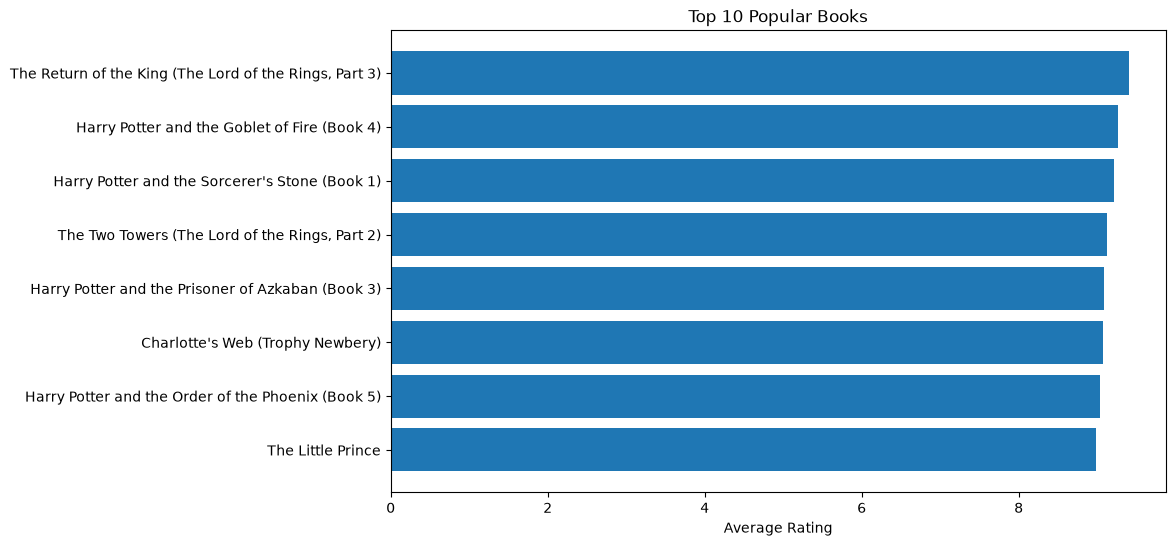

In [14]:
top10 = popular_books.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["Book_Title"],
    top10["avg_rating"]
)

plt.xlabel("Average Rating")
plt.title("Top 10 Popular Books")

plt.gca().invert_yaxis()

plt.show()

In [15]:
def recommend_popular_books(n=10):
    return popular_books.head(n)

In [ ]:
# test recommended books
recommend_popular_books(10)

,Book_Title,Book_Author,Year_Of_Publication,Publisher,avg_rating,num_ratings,Image_URL_L
24538,"The Return of the King (The Lord of the Rings,...",J.R.R. TOLKIEN,1986.0,Del Rey,9.402597,77,http://images.amazon.com/images/P/0345339738.0...
46135,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,2000.0,Scholastic,9.262774,137,http://images.amazon.com/images/P/0439139597.0...
46428,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,2001.0,Scholastic,9.207547,53,http://images.amazon.com/images/P/043936213X.0...
24537,"The Two Towers (The Lord of the Rings, Part 2)",J.R.R. TOLKIEN,1986.0,Del Rey,9.120482,83,http://images.amazon.com/images/P/0345339711.0...
46125,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,2001.0,Scholastic,9.082707,133,http://images.amazon.com/images/P/0439136369.0...
6532,Charlotte's Web (Trophy Newbery),E. B. White,1974.0,HarperTrophy,9.073529,68,http://images.amazon.com/images/P/0064400557.0...
46124,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,1999.0,Scholastic,9.035461,141,http://images.amazon.com/images/P/0439136350.0...
46425,Harry Potter and the Order of the Phoenix (Boo...,J. K. Rowling,2003.0,Scholastic,9.033981,206,http://images.amazon.com/images/P/043935806X.0...
68897,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,1998.0,Scholastic,8.983193,119,http://images.amazon.com/images/P/0590353403.0...
13503,The Little Prince,Antoine de Saint-ExupÃ©ry,1968.0,Harcourt,8.980392,51,http://images.amazon.com/images/P/0156528207.0...
